# Power-law SED method comparison

This notebook compares three SED constructions using controlled power-law point sources with indices (-1, -1.5, -2, -2.5, -3). Every source has the same photon flux integrated across the response energy range. The flux is deliberately modest so that the figures contain both detections and bins with TS below 1.

Each source histogram is generated directly from its spectrum with `SourceInjector.inject_point_source`, written to `powerlaw_injections/` for inspection, and used directly in memory. No precomputed source histogram is loaded. The copied AGN YAML files define and validate the analysis binning, while the DC4 background histogram supplies the background template.

1. **Simultaneous binned SED:** fit all true-energy-bin normalizations together using a fixed local index of (-2), while also fitting one background scale. The normalization fit uses 3ML/Minuit.
2. **Frozen global shape, individual bins:** fit a global power law and background scale, freeze the fitted index and background, and fit one source normalization at a time with 3ML/Minuit in each measured-energy bin.
3. **Frozen global shape, simultaneous bins:** freeze the same global index and background, but fit all true-energy-bin normalizations together with 3ML/Minuit.

A point is shown as a one-sided 95% profile-likelihood upper limit when (mathrm{TS}<1). All three methods use the same five data-independent starting differential normalizations, and the valid Minuit solution with the lowest NLL is refined once and retained.

## 1. Imports and configuration

Set the power-law grid, source position, TS threshold, and AGN file/YAML locations.

In [25]:
from pathlib import Path
from functools import lru_cache
import shutil
import tempfile

import cosipy
import astropy.units as u
from astropy.coordinates import SkyCoord
from astromodels import Model, Parameter, PointSource, Powerlaw
from histpy import Histogram
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import brentq, minimize, minimize_scalar
from threeML import DataList, JointLikelihood, PluginPrototype

from cosipy import BinnedData
from cosipy.data_io import EmCDSBinnedData
from cosipy.response import BinnedInstrumentResponse, PointSourceResponse
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.source_injector import SourceInjector
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.threeml import BinnedSED


# Consistent DC4 orientation, response, and background products.
DC4_DATA_DIR = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/"
    "COSI/Radio_Quiet_AGN/DC4_Files"
)

AGN_ORIENTATION_CANDIDATES = [
    DC4_DATA_DIR / "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits",
]
AGN_RESPONSE_CANDIDATES = [
    DC4_DATA_DIR / (
        "ResponseContinuum.o3.e100_10000.b10log."
        "s10396905069491.m2284.filtered.nonsparse.binnedimaging."
        "imagingresponse.h5"
    ),
]
AGN_BACKGROUND_CANDIDATES = [
    DC4_DATA_DIR / (
        "Background/Total_DC4_BG_3months_binned_data_filtered_"
        "with_SAAcut_withSAAbck_NGC4151_60deg_fov_cut.hdf5"
    ),
]
AGN_YAML_NAMES = (
    "background.yaml",
    "NGC4151_ec200.yaml",
    "NGC4151_ec1000.yaml",
)
AGN_YAML_SEARCH_DIRS = (
    Path("."),
    Path("docs/tutorials/spectral_fits/sed_model"),
    Path(cosipy.__file__).resolve().parents[1]
    / "docs/tutorials/spectral_fits/sed_model",
)

POWERLAW_INDICES = (-1.0, -1.5, -2.0, -2.5, -3.0)
LOCAL_SED_INDEX = -2.0
INITIAL_BIN_FLUX = 1.0e-7  # common, data-independent starting K_i
MINUIT_START_FLUXES = (1.0e-9, 1.0e-8, 1.0e-7, 1.0e-6, 1.0e-5)
TS_THRESHOLD = 1.0
INTEGRATED_PHOTON_FLUX = 3.0e-4  # chosen to produce detections and TS < 1 bins
POWERLAW_PIVOT_KEV = 200.0
SOURCE_LONGITUDE_DEG = 155.07
SOURCE_LATITUDE_DEG = 75.06
PHOTON_FLUX_DENSITY_UNIT = 1.0 / (u.keV * u.cm**2 * u.s)



## 2. AGN input and spectrum helpers

Resolve the copied YAML files and AGN inputs, handle the legacy orientation/response formats, and construct unit-aware power laws.

In [26]:

def _first_existing_path(candidates, label):
    for path in candidates:
        if path.exists():
            return path
    attempted = "\n".join(f"  - {path}" for path in candidates)
    raise FileNotFoundError(f"Could not find the {label}. Tried:\n{attempted}")


def _resolve_agn_yamls():
    return {
        name: _first_existing_path(
            [directory / name for directory in AGN_YAML_SEARCH_DIRS],
            f"copied AGN YAML {name}",
        )
        for name in AGN_YAML_NAMES
    }


def _dense_values(histogram):
    values = histogram.contents
    if hasattr(values, "todense"):
        values = values.todense()
    if isinstance(values, u.Quantity):
        values = values.value
    return np.asarray(values, dtype=float)


def _open_agn_orientation(path):
    """Open the branch .ori file, tolerating its missing final EN marker."""
    try:
        return SpacecraftHistory.open(path)
    except ValueError as error:
        if "must end with final line 'EN'" not in str(error):
            raise
        with tempfile.NamedTemporaryFile(suffix=".ori") as repaired:
            with path.open("rb") as original:
                shutil.copyfileobj(original, repaired)
            repaired.write(b"EN\n")
            repaired.flush()
            return SpacecraftHistory.open(repaired.name)


def _open_compatible_response(candidates):
    """Prefer the branch response, skipping legacy formats this reader rejects."""
    failures = []
    for path in candidates:
        if not path.exists():
            continue
        try:
            return path, FullDetectorResponse.open(path)
        except RuntimeError as error:
            if "Response format is version" not in str(error):
                raise
            failures.append(f"{path}: {error}")
    detail = "\n".join(failures) or "no candidate files exist"
    raise RuntimeError(f"No compatible AGN response was found:\n{detail}")


def _axis_edges_keV(axis):
    edges = axis.edges
    if isinstance(edges, u.Quantity):
        return np.asarray(edges.to_value(u.keV), dtype=float)
    return np.asarray(edges, dtype=float)


def _powerlaw_integral_coefficient(index, pivot, elo, ehi):
    if np.isclose(index, -1.0):
        return pivot * np.log(ehi / elo)
    return (
        pivot ** (-index)
        * (ehi ** (index + 1.0) - elo ** (index + 1.0))
        / (index + 1.0)
    )


def _make_powerlaw(index, normalization, pivot=POWERLAW_PIVOT_KEV):
    spectrum = Powerlaw()
    spectrum.set_units(u.keV, PHOTON_FLUX_DENSITY_UNIT)
    spectrum.K.value = float(normalization)
    spectrum.piv.value = float(pivot)
    spectrum.index.value = float(index)
    return spectrum



## 3. Likelihood and interval helpers

Use a Poisson likelihood for positive detector-space templates and conditional profile-likelihood intervals. The one-sided 95% limit uses delta NLL = 1.355.

All BinnedSED, frozen-index simultaneous, and frozen-index individual normalization fits use the same 3ML/Minuit multi-start procedure. Each fit is tried from five fixed, data-independent normalization values; the valid solution with the lowest NLL is then refined once. The trial diagnostics are retained so convergence and agreement between starts can be checked explicitly.

For the frozen-index method, the `BinnedSED` normalization parameters are only the 3ML parameter container. The plugin evaluates those parameters against the precomputed detector templates that retain the globally fitted power-law index.

In [27]:

def _poisson_nll(data, model):
    """Poisson deviance / 2, with the saturated-model constant removed."""
    model = np.clip(np.asarray(model, dtype=float), np.finfo(float).tiny, None)
    data = np.asarray(data, dtype=float)
    positive = data > 0.0
    value = np.sum(model[~positive])
    value += np.sum(
        model[positive]
        - data[positive]
        + data[positive] * np.log(data[positive] / model[positive])
    )
    return float(value)


def _fit_positive_components(data, components, start=None, fixed_model=None):
    """Fit non-negative amplitudes multiplying fixed detector-space templates."""
    data = np.asarray(data, dtype=float).ravel()
    components = np.asarray(components, dtype=float).reshape(len(components), -1)
    if fixed_model is None:
        fixed_model = np.zeros_like(data)
    else:
        fixed_model = np.asarray(fixed_model, dtype=float).ravel()

    if start is None:
        start = np.ones(components.shape[0])
    start = np.clip(np.asarray(start, dtype=float), 1.0e-30, None)

    # Parameterize each coefficient by its expected component counts. This
    # removes the enormous column-scale differences produced by steep cutoffs.
    component_sums = np.sum(components, axis=1)
    if np.any(~np.isfinite(component_sums)) or np.any(component_sums <= 0.0):
        raise ValueError("Every fitted component must have a positive finite sum.")
    normalized_components = components / component_sums[:, None]
    expected_counts = start * component_sums
    tiny = np.finfo(float).tiny

    # Multiplicative Poisson updates provide a robust warm start while retaining
    # the exact physical starting amplitudes supplied above.
    for _ in range(100):
        raw_model = fixed_model + expected_counts @ normalized_components
        model = np.clip(raw_model, tiny, None)
        ratio = np.zeros_like(data)
        supported = (raw_model > tiny) & (data > 0.0)
        with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
            ratio[supported] = data[supported] / model[supported]
        ratio = np.nan_to_num(ratio, nan=0.0, posinf=1.0e100, neginf=0.0)
        updated_counts = expected_counts * (normalized_components @ ratio)
        updated_counts = np.nan_to_num(
            updated_counts, nan=0.0, posinf=1.0e100, neginf=0.0
        )
        relative_change = np.max(
            np.abs(updated_counts - expected_counts) / (1.0 + expected_counts)
        )
        expected_counts = updated_counts
        if relative_change < 1.0e-8:
            break

    variable_scales = np.maximum(expected_counts, 1.0)
    scaled_components = variable_scales[:, None] * normalized_components

    def objective(relative_counts):
        raw_model = fixed_model + relative_counts @ scaled_components
        model = np.clip(raw_model, tiny, None)
        nll = _poisson_nll(data, model)
        score = np.zeros_like(model)
        supported = raw_model > tiny
        score[supported] = 1.0 - data[supported] / model[supported]
        gradient = scaled_components @ score
        return nll, gradient

    bounds = [(0.0, None)] * components.shape[0]
    result = minimize(
        objective,
        x0=expected_counts / variable_scales,
        method="L-BFGS-B",
        jac=True,
        bounds=bounds,
        options={
            "ftol": 1.0e-13,
            "gtol": 1.0e-9,
            "maxiter": 8000,
            "maxls": 100,
        },
    )
    if not result.success:
        result = minimize(
            objective,
            x0=np.clip(result.x, 0.0, None),
            method="SLSQP",
            jac=True,
            bounds=bounds,
            options={"ftol": 1.0e-11, "maxiter": 8000},
        )
    if not result.success:
        raise RuntimeError(f"Component fit failed: {result.message}")

    amplitudes = variable_scales * result.x / component_sums
    model = fixed_model + amplitudes @ components
    return amplitudes, _poisson_nll(data, model)


class _TemplatePoissonPlugin(PluginPrototype):
    """3ML plugin for non-negative amplitudes of folded detector templates."""

    def __init__(
        self,
        name,
        data,
        templates,
        background,
        spectrum,
        reference_flux,
        background_start,
        background_free,
    ):
        self._data = np.asarray(data, dtype=float).ravel()
        self._templates = np.asarray(templates, dtype=float).reshape(
            len(templates), -1
        )
        self._background = np.asarray(background, dtype=float).ravel()
        self._normalizations = tuple(spectrum.normalizations)
        self._reference_flux = float(reference_flux)
        if self._templates.shape[0] != len(self._normalizations):
            raise ValueError("Each Minuit normalization needs one template.")
        if self._templates.shape[1] != self._data.size:
            raise ValueError("Template and data shapes do not match.")
        if self._background.size != self._data.size:
            raise ValueError("Background and data shapes do not match.")

        background_name = f"{name}_background_scale"
        self.background_scale = Parameter(
            background_name,
            float(background_start),
            min_value=0.0,
            max_value=10.0,
            delta=0.05,
            free=bool(background_free),
        )
        super().__init__(name, {background_name: self.background_scale})
        self._model = None

    def set_model(self, model):
        self._model = model

    def get_number_of_data_points(self):
        return int(self._data.size)

    def get_log_like(self):
        amplitudes = np.asarray(
            [parameter.value for parameter in self._normalizations], dtype=float
        ) / self._reference_flux
        model = (
            amplitudes @ self._templates
            + float(self.background_scale.value) * self._background
        )
        return -_poisson_nll(self._data, model)

    def inner_fit(self):
        return self.get_log_like()


def _minuit_status(like):
    """Return the Minuit convergence fields used to rank multi-start fits."""
    fmin = like.minimizer.minuit.fmin
    return {
        "valid": bool(getattr(fmin, "is_valid", False)),
        "edm": float(getattr(fmin, "edm", np.nan)),
        "call_limit": bool(getattr(fmin, "has_reached_call_limit", False)),
        "above_max_edm": bool(getattr(fmin, "is_above_max_edm", False)),
        "at_limit": bool(getattr(fmin, "has_parameters_at_limit", False)),
    }


def _fit_templates_with_minuit(
    data,
    templates,
    background,
    detector_response,
    ei_bin_indices,
    reference_flux,
    local_index,
    start_fluxes,
    background_start,
    background_free,
    fit_tag,
):
    """Fit template amplitudes with 3ML/Minuit from several fixed starts."""
    starts = tuple(float(value) for value in start_fluxes)
    if not starts or any((not np.isfinite(value) or value <= 0.0) for value in starts):
        raise ValueError("Minuit starting fluxes must be finite and positive.")

    bins = tuple(int(index) for index in ei_bin_indices)
    spectrum = BinnedSED.from_response(
        detector_response,
        ei_bin_indices=bins,
        initial_fluxes=[starts[0]] * len(bins),
        index=local_index,
    )
    for parameter in spectrum.normalizations:
        parameter.min_value = 0.0
        parameter.max_value = 1.0e-2
        parameter.delta = max(0.2 * starts[0], 1.0e-12)
        parameter.free = True

    source = PointSource(
        f"source_{fit_tag}",
        l=SOURCE_LONGITUDE_DEG,
        b=SOURCE_LATITUDE_DEG,
        spectral_shape=spectrum,
    )
    model = Model(source)
    plugin = _TemplatePoissonPlugin(
        f"plugin_{fit_tag}",
        data,
        templates,
        background,
        spectrum,
        reference_flux,
        background_start,
        background_free,
    )
    like = JointLikelihood(
        model, DataList(plugin), verbose=False, record=False
    )
    like.set_minimizer("minuit")

    trial_rows = []
    candidates = []
    for start_flux in starts:
        for parameter in spectrum.normalizations:
            parameter.value = start_flux
            parameter.delta = max(0.2 * start_flux, 1.0e-12)
            parameter.free = True
        plugin.background_scale.value = float(background_start)
        plugin.background_scale.free = bool(background_free)

        try:
            like.fit(quiet=True, compute_covariance=False)
            status = _minuit_status(like)
            nll = float(like.current_minimum)
            values = np.asarray(
                [parameter.value for parameter in spectrum.normalizations],
                dtype=float,
            )
            background_value = float(plugin.background_scale.value)
            error = ""
        except Exception as exc:
            status = {
                "valid": False,
                "edm": np.nan,
                "call_limit": False,
                "above_max_edm": False,
                "at_limit": False,
            }
            nll = np.inf
            values = None
            background_value = np.nan
            error = f"{type(exc).__name__}: {exc}"

        trial_rows.append(
            {
                "fit_tag": fit_tag,
                "stage": "multi-start",
                "start_flux": start_flux,
                "nll": nll,
                "background_scale": background_value,
                "error": error,
                **status,
            }
        )
        if status["valid"] and np.isfinite(nll):
            candidates.append((nll, values.copy(), background_value))

    if not candidates:
        diagnostics = pd.DataFrame(trial_rows)
        raise RuntimeError(
            f"No valid Minuit solution for {fit_tag}.\n{diagnostics.to_string(index=False)}"
        )

    best_nll, best_values, best_background = min(candidates, key=lambda item: item[0])
    for parameter, value in zip(spectrum.normalizations, best_values):
        parameter.value = float(value)
        parameter.delta = max(0.2 * max(float(value), starts[0]), 1.0e-12)
    plugin.background_scale.value = best_background

    # One final MIGRAD pass starts from the best valid multi-start solution.
    try:
        like.fit(quiet=True, compute_covariance=False)
        refine_status = _minuit_status(like)
        refine_nll = float(like.current_minimum)
        refine_values = np.asarray(
            [parameter.value for parameter in spectrum.normalizations], dtype=float
        )
        refine_background = float(plugin.background_scale.value)
        refine_error = ""
    except Exception as exc:
        refine_status = {
            "valid": False,
            "edm": np.nan,
            "call_limit": False,
            "above_max_edm": False,
            "at_limit": False,
        }
        refine_nll = np.inf
        refine_values = None
        refine_background = np.nan
        refine_error = f"{type(exc).__name__}: {exc}"

    trial_rows.append(
        {
            "fit_tag": fit_tag,
            "stage": "refine",
            "start_flux": np.nan,
            "nll": refine_nll,
            "background_scale": refine_background,
            "error": refine_error,
            **refine_status,
        }
    )
    if refine_status["valid"] and refine_nll <= best_nll:
        best_nll = refine_nll
        best_values = refine_values.copy()
        best_background = refine_background

    for parameter, value in zip(spectrum.normalizations, best_values):
        parameter.value = float(value)
    plugin.background_scale.value = float(best_background)

    objectives = []
    for parameter in spectrum.normalizations:
        def objective(scale, parameter=parameter):
            saved_value = float(parameter.value)
            try:
                parameter.value = max(float(scale), 0.0) * reference_flux
                return -float(plugin.get_log_like())
            finally:
                parameter.value = saved_value

        objectives.append(objective)

    return {
        "amplitudes": best_values / reference_flux,
        "nll": float(best_nll),
        "background_scale": float(best_background),
        "objectives": tuple(objectives),
        "trials": pd.DataFrame(trial_rows),
        "like": like,
        "plugin": plugin,
        "spectrum": spectrum,
    }


def _profile_root(objective, best, nll_best, delta_nll, direction):
    def crossing(value):
        return objective(value) - nll_best - delta_nll

    if direction < 0:
        if best <= 0.0 or crossing(0.0) < 0.0:
            return 0.0
        return float(brentq(crossing, 0.0, best))

    upper = max(2.0 * best, best + 1.0, 1.0)
    for _ in range(60):
        if crossing(upper) >= 0.0:
            return float(brentq(crossing, best, upper))
        upper *= 2.0
    return np.nan


def _conditional_summary(best, nll_best, objective):
    """TS, conditional 68% interval, and one-sided 95% UL for one amplitude."""
    ts = max(0.0, 2.0 * (objective(0.0) - nll_best))
    low = _profile_root(objective, best, nll_best, 0.5, -1)
    high = _profile_root(objective, best, nll_best, 0.5, +1)
    ul95 = _profile_root(objective, best, nll_best, 1.355, +1)
    return ts, low, high, ul95


## 4. Source injection and comparison driver

Load and validate the AGN binning, build the point response, create every source file with `SourceInjector.inject_point_source`, and run both SED methods.

In [28]:
def compare_powerlaw_sed_methods(
    indices=POWERLAW_INDICES,
    integrated_photon_flux=INTEGRATED_PHOTON_FLUX,
    local_sed_index=LOCAL_SED_INDEX,
    initial_bin_flux=INITIAL_BIN_FLUX,
    minuit_start_fluxes=MINUIT_START_FLUXES,
    ts_threshold=TS_THRESHOLD,
    injection_output_dir="powerlaw_injections",
):
    """
    Compare simultaneous BinnedSED points with frozen-global-shape points.

    SourceInjector generates and saves each injected power-law histogram. The
    returned histogram is combined with the AGN background as deterministic
    Asimov data. The simultaneous fit floats every BinnedSED
    normalization and one global background scale. The frozen-shape methods
    first fit a global power law and background scale, then freeze that shape
    and background. All simultaneous and individual normalization fits use
    the same 3ML/Minuit multi-start grid, independent of the data and
    injected normalization.

    Returns
    -------
    sed_results : pandas.DataFrame
        One row per injected index, method, and energy bin.
    global_fits : pandas.DataFrame
        Best global power-law and background parameters.
    run_info : dict
        Resolved files and key analysis settings.
    """
    orientation_path = _first_existing_path(
        AGN_ORIENTATION_CANDIDATES, "AGN orientation file"
    )
    response_path, detector_response = _open_compatible_response(
        AGN_RESPONSE_CANDIDATES
    )
    background_path = _first_existing_path(
        AGN_BACKGROUND_CANDIDATES, "AGN background file"
    )
    yaml_paths = _resolve_agn_yamls()

    # Load the existing background through the copied AGN configuration.
    agn_configs = {name: BinnedData(path) for name, path in yaml_paths.items()}
    background_data = agn_configs["background.yaml"]
    background_data.load_binned_data_from_hdf5(background_path)
    background_hist = background_data.binned_data.project("Em", "Phi", "PsiChi")
    data_definition = EmCDSBinnedData(background_hist)
    background_counts = _dense_values(background_hist)

    orientation = _open_agn_orientation(orientation_path)
    instrument_response = BinnedInstrumentResponse(detector_response, data_definition)

    source_coord = SkyCoord(
        l=SOURCE_LONGITUDE_DEG * u.deg,
        b=SOURCE_LATITUDE_DEG * u.deg,
        frame="galactic",
    )
    scatt_map = orientation.get_scatt_map(
        nside=2 * data_definition.axes["PsiChi"].nside,
        target_coord=source_coord,
        earth_occ=True,
    )
    point_response = PointSourceResponse.from_scatt_map(
        source_coord,
        data_definition,
        instrument_response,
        scatt_map,
        detector_response.axes["Ei"],
        detector_response.axes["Pol"] if "Pol" in detector_response.axes.labels else None,
    )

    ei_edges = _axis_edges_keV(detector_response.axes["Ei"])
    em_edges = _axis_edges_keV(data_definition.axes["Em"])
    if not np.allclose(ei_edges, em_edges):
        raise ValueError(
            "This compact comparison requires matching Ei and Em edges so the "
            "two methods can be plotted and differenced bin by bin."
        )
    for yaml_name, config in agn_configs.items():
        if not np.allclose(np.asarray(config.energy_bins, dtype=float), em_edges):
            raise ValueError(f"Energy bins in {yaml_name} do not match the data.")
        if int(180 / config.phi_pix_size) != data_definition.axes["Phi"].nbins:
            raise ValueError(f"Phi bins in {yaml_name} do not match the data.")
        if int(config.nside) != data_definition.axes["PsiChi"].nside:
            raise ValueError(f"PsiChi nside in {yaml_name} does not match the data.")

    energy = np.sqrt(ei_edges[:-1] * ei_edges[1:])
    n_energy_bins = energy.size
    base_k = 1.0e-6
    if not np.isfinite(initial_bin_flux) or initial_bin_flux <= 0.0:
        raise ValueError("initial_bin_flux must be finite and positive.")
    minuit_start_fluxes = tuple(map(float, minuit_start_fluxes))
    if not minuit_start_fluxes or any(
        (not np.isfinite(value) or value <= 0.0)
        for value in minuit_start_fluxes
    ):
        raise ValueError("minuit_start_fluxes must be finite and positive.")
    injection_output_dir = Path(injection_output_dir)
    injection_output_dir.mkdir(parents=True, exist_ok=True)
    injector = SourceInjector(response_path=response_path)
    injection_files = []

    @lru_cache(maxsize=None)
    def folded_powerlaw(index):
        model = _make_powerlaw(index, base_k)
        return _dense_values(point_response.get_expectation(model))

    # Unit-amplitude templates for the current simultaneous BinnedSED method.
    sed_templates = []
    for bin_index in range(n_energy_bins):
        local_model = BinnedSED.from_response(
            detector_response,
            ei_bin_indices=[bin_index],
            initial_fluxes=[base_k],
            index=local_sed_index,
        )
        local_model.set_units(u.keV, PHOTON_FLUX_DENSITY_UNIT)
        sed_templates.append(_dense_values(point_response.get_expectation(local_model)))
    sed_templates = np.asarray(sed_templates)

    rows = []
    global_rows = []
    minuit_trial_tables = []

    for injected_index in map(float, indices):
        band_coefficient = _powerlaw_integral_coefficient(
            injected_index,
            POWERLAW_PIVOT_KEV,
            ei_edges[0],
            ei_edges[-1],
        )
        injected_k = float(integrated_photon_flux / band_coefficient)
        injected_spectrum = _make_powerlaw(injected_index, injected_k)
        index_tag = f"{injected_index:g}".replace("-", "m").replace(".", "p")
        injection_file = injection_output_dir / f"powerlaw_index_{index_tag}.h5"
        if injection_file.exists():
            injection_file.unlink()
        injected_hist = injector.inject_point_source(
            spectrum=injected_spectrum,
            coordinate=source_coord,
            orientation=orientation,
            source_name=f"powerlaw_index_{index_tag}",
            data_save_path=injection_file,
            project_axes=["Em", "Phi", "PsiChi"],
            earth_occ=True,
        )
        injected_signal = _dense_values(injected_hist)
        if injected_signal.shape != background_counts.shape:
            raise ValueError(
                f"Injected/source shape {injected_signal.shape} does not match "
                f"background shape {background_counts.shape}."
            )
        injection_files.append(injection_file.resolve())
        asimov_counts = background_counts + injected_signal

        # Global fit used only to define the frozen spectral shape/background.
        def fit_at_index(trial_index):
            trial_shape = folded_powerlaw(float(trial_index))
            amplitudes, nll = _fit_positive_components(
                asimov_counts,
                np.stack([trial_shape, background_counts]),
                start=[initial_bin_flux / base_k, 1.0],
            )
            return nll, amplitudes

        def global_index_objective(trial_index):
            return fit_at_index(trial_index)[0]

        index_fit = minimize_scalar(
            global_index_objective,
            bounds=(-4.5, -0.5),
            method="bounded",
            options={"xatol": 2.0e-4},
        )
        if not index_fit.success:
            raise RuntimeError(f"Global power-law fit failed: {index_fit.message}")

        fitted_index = float(index_fit.x)
        global_nll, global_amplitudes = fit_at_index(fitted_index)
        fitted_k = float(global_amplitudes[0] * base_k)
        fitted_background_scale = float(global_amplitudes[1])
        fitted_global_template = folded_powerlaw(fitted_index)

        global_rows.append(
            {
                "injected_index": injected_index,
                "injected_K": injected_k,
                "fitted_index": fitted_index,
                "fitted_K": fitted_k,
                "background_scale": fitted_background_scale,
                "nll": global_nll,
            }
        )

        # Method 1: all BinnedSED normalizations and one background scale.
        binned_fit = _fit_templates_with_minuit(
            data=asimov_counts,
            templates=sed_templates,
            background=background_counts,
            detector_response=detector_response,
            ei_bin_indices=range(n_energy_bins),
            reference_flux=base_k,
            local_index=local_sed_index,
            start_fluxes=minuit_start_fluxes,
            background_start=1.0,
            background_free=True,
            fit_tag=f"binned_index_{index_tag}",
        )
        minuit_trial_tables.append(
            binned_fit["trials"].assign(
                injected_index=injected_index,
                method="simultaneous BinnedSED",
                fit_bin="all",
            )
        )

        for bin_index in range(n_energy_bins):
            best_scale = float(binned_fit["amplitudes"][bin_index])
            ts, low, high, ul95 = _conditional_summary(
                best_scale,
                binned_fit["nll"],
                binned_fit["objectives"][bin_index],
            )
            rows.append(
                {
                    "injected_index": injected_index,
                    "method": "simultaneous BinnedSED",
                    "bin": bin_index,
                    "energy_keV": energy[bin_index],
                    "flux": best_scale * base_k,
                    "flux_low": low * base_k,
                    "flux_high": high * base_k,
                    "ul95": ul95 * base_k,
                    "TS": ts,
                    "is_ul": ts < ts_threshold,
                    "background_scale": binned_fit["background_scale"],
                }
            )

        # Method 2: freeze the fitted global index/background, but fit all
        # true-energy-bin normalizations simultaneously.
        frozen_sed_templates = []
        for bin_index in range(n_energy_bins):
            frozen_bin_model = BinnedSED.from_response(
                detector_response,
                ei_bin_indices=[bin_index],
                initial_fluxes=[base_k],
                index=fitted_index,
            )
            frozen_bin_model.set_units(u.keV, PHOTON_FLUX_DENSITY_UNIT)
            frozen_sed_templates.append(
                _dense_values(point_response.get_expectation(frozen_bin_model))
            )
        frozen_sed_templates = np.asarray(frozen_sed_templates)
        frozen_sim_fit = _fit_templates_with_minuit(
            data=asimov_counts,
            templates=frozen_sed_templates,
            background=background_counts,
            detector_response=detector_response,
            ei_bin_indices=range(n_energy_bins),
            reference_flux=base_k,
            local_index=fitted_index,
            start_fluxes=minuit_start_fluxes,
            background_start=fitted_background_scale,
            background_free=False,
            fit_tag=f"frozen_index_{index_tag}",
        )
        minuit_trial_tables.append(
            frozen_sim_fit["trials"].assign(
                injected_index=injected_index,
                method="simultaneous frozen global shape",
                fit_bin="all",
            )
        )

        for bin_index in range(n_energy_bins):
            best_scale = float(frozen_sim_fit["amplitudes"][bin_index])
            ts, low, high, ul95 = _conditional_summary(
                best_scale,
                frozen_sim_fit["nll"],
                frozen_sim_fit["objectives"][bin_index],
            )
            rows.append(
                {
                    "injected_index": injected_index,
                    "method": "simultaneous frozen global shape",
                    "bin": bin_index,
                    "energy_keV": energy[bin_index],
                    "flux": best_scale * base_k,
                    "flux_low": low * base_k,
                    "flux_high": high * base_k,
                    "ul95": ul95 * base_k,
                    "TS": ts,
                    "is_ul": ts < ts_threshold,
                    "background_scale": fitted_background_scale,
                }
            )

        # Method 3: global index and background are frozen. One source
        # normalization is fitted with 3ML/Minuit in each measured-energy bin.
        for bin_index in range(n_energy_bins):
            data_slice = asimov_counts[bin_index, ...]
            shape_at_pivot = (
                (energy[bin_index] / POWERLAW_PIVOT_KEV) ** fitted_index
            )
            signal_slice = (
                fitted_global_template[bin_index, ...] / shape_at_pivot
            )
            individual_fit = _fit_templates_with_minuit(
                data=data_slice,
                templates=np.asarray([signal_slice]),
                background=background_counts[bin_index, ...],
                detector_response=detector_response,
                ei_bin_indices=[bin_index],
                reference_flux=base_k,
                local_index=fitted_index,
                start_fluxes=minuit_start_fluxes,
                background_start=fitted_background_scale,
                background_free=False,
                fit_tag=f"individual_index_{index_tag}_bin_{bin_index}",
            )
            minuit_trial_tables.append(
                individual_fit["trials"].assign(
                    injected_index=injected_index,
                    method="frozen global shape",
                    fit_bin=str(bin_index),
                )
            )
            best_scale = float(individual_fit["amplitudes"][0])
            ts, low, high, ul95 = _conditional_summary(
                best_scale,
                individual_fit["nll"],
                individual_fit["objectives"][0],
            )
            rows.append(
                {
                    "injected_index": injected_index,
                    "method": "frozen global shape",
                    "bin": bin_index,
                    "energy_keV": energy[bin_index],
                    "flux": best_scale * base_k,
                    "flux_low": low * base_k,
                    "flux_high": high * base_k,
                    "ul95": ul95 * base_k,
                    "TS": ts,
                    "is_ul": ts < ts_threshold,
                    "background_scale": fitted_background_scale,
                }
            )

    run_info = {
        "orientation": orientation_path,
        "response": response_path,
        "background": background_path,
        "yaml_files": yaml_paths,
        "injection_files": tuple(injection_files),
        "indices": tuple(map(float, indices)),
        "local_sed_index": float(local_sed_index),
        "ts_threshold": float(ts_threshold),
        "integrated_photon_flux": float(integrated_photon_flux),
        "initial_bin_flux": float(initial_bin_flux),
        "minuit_start_fluxes": minuit_start_fluxes,
        "minuit_trials": pd.concat(minuit_trial_tables, ignore_index=True),
        "energy_edges_keV": ei_edges,
    }
    return pd.DataFrame(rows), pd.DataFrame(global_rows), run_info

## 5. Generate the injections and run the fits

This is the expensive cell. It builds the point-source response once, injects five power laws, globally fits each index, and evaluates all three SED methods. Each simultaneous fit and each of the ten individual measured-energy-bin fits run five 3ML/Minuit starts plus one refinement fit.

In [29]:
# Building the point-source response from the 6.6 GB AGN response can take a few minutes.
sed_comparison, global_powerlaw_fits, comparison_info = compare_powerlaw_sed_methods()

print("Files used:")
for label in ("orientation", "response", "background"):
    print(f"  {label}: {comparison_info[label]}")
print("\nCopied AGN YAML configurations:")
for label, path in comparison_info["yaml_files"].items():
    print(f"  {label}: {path}")
print("\nPoint-source injection files created from the spectra:")
for path in comparison_info["injection_files"]:
    print(f"  {path}")

print("\nGlobal fits (the shape/background subsequently frozen in method 2):")
display(global_powerlaw_fits)

minuit_trials = comparison_info["minuit_trials"]
multi_start_trials = minuit_trials[minuit_trials["stage"] == "multi-start"]
minuit_convergence_summary = (
    multi_start_trials.groupby(
        ["injected_index", "method", "fit_bin"], as_index=False
    )
    .agg(
        valid_starts=("valid", "sum"),
        attempted_starts=("valid", "size"),
        best_nll=("nll", "min"),
        any_call_limit=("call_limit", "any"),
        any_above_max_edm=("above_max_edm", "any"),
    )
)
print("\n3ML/Minuit multi-start convergence summary:")
display(minuit_convergence_summary)


20:09:56 INFO      set the minimizer to minuit                                             ]8;id=433721;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=628096;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to MINUIT                                             ]8;id=340313;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=509413;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1034\1034]8;;\

20:10:16 INFO      set the minimizer to minuit                                             ]8;id=855652;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=906923;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

         INFO      set the minimizer to MINUIT                                             ]8;id=292892;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=969191;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1034\1034]8;;\

20:10:31 INFO      set the minimizer to minuit                                             ]8;id=682374;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=30800;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

...

         INFO      set the minimizer to MINUIT                                             ]8;id=858847;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=343314;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1034\1034]8;;\

Files used:
  orientation: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits
  response: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5
  background: /Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Radio_Quiet_AGN/DC4_Files/Background/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_NGC4151_60deg_fov_cut.hdf5

Copied AGN YAML configurations:
  background.yaml: background.yaml
  NGC4151_ec200.yaml: NGC4151_ec200.yaml
  NGC4151_ec1000.yaml: NGC4151_ec1000.yaml

Point-source injection files created from the spectra:
  /Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/sed_model/powerlaw_injections/powerlaw_index_m1.h5
  /Users/parshadkp/Software/cosipy/docs/tutorials/spect

,injected_index,injected_K,fitted_index,fitted_K,background_scale,nll
0,-1.0,3.257209e-07,-0.999972,3.256964e-07,1.0,2.087294e-08
1,-1.5,5.892557e-07,-1.500022,5.892829e-07,1.0,1.131925e-08
2,-2.0,7.575758e-07,-2.000033,7.576030e-07,1.0,1.291913e-08
3,-2.5,7.962914e-07,-2.500003,7.962922e-07,1.0,3.459619e-11
4,-3.0,7.500750e-07,-3.000009,7.500745e-07,1.0,1.407857e-10



3ML/Minuit multi-start convergence summary:


,injected_index,method,fit_bin,valid_starts,attempted_starts,best_nll,any_call_limit,any_above_max_edm
0,-3.0,frozen global shape,0,5,5,2.626898e-09,False,False
1,-3.0,frozen global shape,1,5,5,3.928140e-11,False,False
2,-3.0,frozen global shape,2,5,5,8.141514e-10,False,False
3,-3.0,frozen global shape,3,5,5,1.482618e-09,False,False
4,-3.0,frozen global shape,4,5,5,5.860523e-10,False,False
5,-3.0,frozen global shape,5,5,5,1.576609e-07,False,False
6,-3.0,frozen global shape,6,5,5,6.232420e-10,False,False
7,-3.0,frozen global shape,7,5,5,2.829771e-08,False,False
8,-3.0,frozen global shape,8,5,5,1.024111e-09,False,False
9,-3.0,frozen global shape,9,5,5,2.212748e-11,False,False


## 6. Accuracy, TS, and upper-limit comparison

The wide table reports the median absolute residual from differential truth at the bin center, using detections only. Bins with $TS<1$ are counted separately as upper limits and are not treated as flux measurements.

In [37]:
def _powerlaw_truth(index, energy_keV):
    injected_k = global_powerlaw_fits.loc[
        global_powerlaw_fits["injected_index"] == float(index),
        "injected_K",
    ].iloc[0]
    return float(injected_k) * (
        np.asarray(energy_keV, dtype=float) / POWERLAW_PIVOT_KEV
    ) ** float(index)


summary_rows = []
for injected_index in comparison_info["indices"]:
    selected = sed_comparison[
        sed_comparison["injected_index"] == injected_index
    ]
    for method, group in selected.groupby("method"):
        truth = _powerlaw_truth(
            injected_index, group["energy_keV"].to_numpy()
        )
        detected = ~group["is_ul"].to_numpy(dtype=bool)
        residual = 100.0 * (group["flux"].to_numpy() - truth) / truth
        summary_rows.append(
            {
                "injected_index": injected_index,
                "method": method,
                "detections": int(detected.sum()),
                "upper_limits": int((~detected).sum()),
                "median_abs_residual_percent": (
                    float(np.median(np.abs(residual[detected])))
                    if detected.any() else np.nan
                ),
            }
        )
accuracy_summary = pd.DataFrame(summary_rows)

method_labels = {
    "simultaneous BinnedSED": "BinnedSED",
    "simultaneous frozen global shape": "Simultaneous frozen shape",
    "frozen global shape": "Individual measured-energy",
}
method_order = list(method_labels.values())
median_residual_table = (
    accuracy_summary.pivot(
        index="injected_index",
        columns="method",
        values="median_abs_residual_percent",
    )
    .rename(columns=method_labels)
    .reindex(index=comparison_info["indices"], columns=method_order)
)
median_residual_table.index = [
    f"index = {value:g}" for value in median_residual_table.index
]
median_residual_table.index.name = "Injected power law"
median_residual_table.columns.name = None
print("Median absolute residual from injected truth [%]; detections only:")
display(median_residual_table.style.format("{:.3f}", na_rep="—"))

upper_limit_table = (
    accuracy_summary.pivot(
        index="injected_index", columns="method", values="upper_limits"
    )
    .rename(columns=method_labels)
    .reindex(index=comparison_info["indices"], columns=method_order)
)
upper_limit_table.index = median_residual_table.index
upper_limit_table.index.name = "Injected power law"
upper_limit_table.columns.name = None
print("Number of TS < 1 upper limits excluded from the residual table:")
display(upper_limit_table)

upper_limit_summary = (
    sed_comparison
    .groupby(["injected_index", "method"], as_index=False)
    .agg(min_TS=("TS", "min"), upper_limits=("is_ul", "sum"))
)
display(upper_limit_summary)

Median absolute residual from injected truth [%]; detections only:


,BinnedSED,Simultaneous frozen shape,Individual measured-energy
Injected power law,,,
index = -1,0.878,0.003,0.001
index = -1.5,0.659,0.001,0.001
index = -2,0.001,0.000,0.001
index = -2.5,1.107,0.000,0.000
index = -3,2.661,0.000,0.000


Number of TS < 1 upper limits excluded from the residual table:


,BinnedSED,Simultaneous frozen shape,Individual measured-energy
Injected power law,,,
index = -1,1,1,0
index = -1.5,1,1,0
index = -2,3,3,0
index = -2.5,4,4,0
index = -3,6,6,0


,injected_index,method,min_TS,upper_limits
0,-3.0,frozen global shape,14.391426,0
1,-3.0,simultaneous BinnedSED,0.033744,6
2,-3.0,simultaneous frozen global shape,0.033361,6
3,-2.5,frozen global shape,61.418599,0
4,-2.5,simultaneous BinnedSED,0.152888,4
5,-2.5,simultaneous frozen global shape,0.153015,4
6,-2.0,frozen global shape,121.488588,0
7,-2.0,simultaneous BinnedSED,0.596913,3
8,-2.0,simultaneous frozen global shape,0.596794,3
9,-1.5,frozen global shape,146.246189,0


## 7. Per-bin TS tables

Display one table for each SED method. Rows are true-energy bins; each injected power-law index has adjacent TS and upper-limit columns. `upper_limit=True` means $TS < 1$.

In [31]:
from IPython.display import Markdown

TS_METHOD_ORDER = (
    "simultaneous BinnedSED",
    "frozen global shape",
    "simultaneous frozen global shape",
)

ts_tables_by_method = {}

for method in TS_METHOD_ORDER:
    method_results = sed_comparison[
        sed_comparison["method"] == method
    ]
    index_tables = []

    for injected_index in comparison_info["indices"]:
        index_table = (
            method_results[
                method_results["injected_index"] == injected_index
            ][["bin", "energy_keV", "TS", "is_ul"]]
            .sort_values("bin")
            .set_index(["bin", "energy_keV"])
            .rename(columns={"is_ul": "upper_limit"})
        )
        index_tables.append(index_table)

    method_table = pd.concat(
        index_tables,
        axis=1,
        keys=[
            rf"$\alpha={index:g}$"
            for index in comparison_info["indices"]
        ],
        names=["injected_index", "quantity"],
    )
    ts_tables_by_method[method] = method_table

    display(Markdown(f"### {method}"))
    display(
        method_table.style.format(
            {
                column: "{:.3f}"
                for column in method_table.columns
                if column[1] == "TS"
            }
        )
    )

### simultaneous BinnedSED

### frozen global shape

### simultaneous frozen global shape

In [32]:
from matplotlib.lines import Line2D

ALL_COMPARISON_INDICES = tuple(comparison_info["indices"])
UNCERTAINTY_COMPARISON_INDICES = tuple(
    index for index in ALL_COMPARISON_INDICES if index in (-1.0, -2.0, -3.0)
)
COMPARISON_COLORS = dict(
    zip(
        ALL_COMPARISON_INDICES,
        plt.cm.viridis(np.linspace(0.08, 0.92, len(ALL_COMPARISON_INDICES))),
    )
)


def _displayed_sed_value(table):
    """Use fitted flux for detections and the plotted 95% limit for UL bins."""
    is_ul = table["is_ul"].to_numpy(dtype=bool)
    value = np.where(is_ul, table["ul95"], table["flux"]).astype(float)
    return value, is_ul


def _draw_sed_points(
    ax,
    table,
    color,
    marker,
    filled,
    x_offset,
    show_uncertainties,
):
    """Draw detections and upper limits, optionally with detection error bars."""
    table = table.sort_values("bin").reset_index(drop=True)
    energy = table["energy_keV"].to_numpy()
    flux = table["flux"].to_numpy()
    detected = ~table["is_ul"].to_numpy(dtype=bool)
    upper = ~detected
    x = x_offset * energy
    y = energy**2 * flux
    marker_face = color if filled else "white"

    if show_uncertainties:
        yerr = np.vstack(
            [
                energy**2 * (flux - table["flux_low"].to_numpy()),
                energy**2 * (table["flux_high"].to_numpy() - flux),
            ]
        )
        ax.errorbar(
            x[detected],
            y[detected],
            yerr=yerr[:, detected],
            fmt=marker,
            ms=5.5,
            color=color,
            markerfacecolor=marker_face,
            markeredgewidth=1.2,
            capsize=2,
            linestyle="none",
        )
    else:
        ax.plot(
            x[detected],
            y[detected],
            marker=marker,
            ms=5.5,
            color=color,
            markerfacecolor=marker_face,
            markeredgewidth=1.2,
            linestyle="none",
        )

    plotted = list(y[detected])
    if np.any(upper):
        ul_y = energy[upper] ** 2 * table.loc[upper, "ul95"].to_numpy()

        if show_uncertainties:
            ax.errorbar(
                x[upper],
                ul_y,
                yerr=0.28 * ul_y,
                uplims=True,
                fmt=marker,
                ms=5.5,
                color=color,
                markerfacecolor=marker_face,
                markeredgewidth=1.2,
                linestyle="none",
            )
        else:
            ax.plot(
                x[upper],
                ul_y,
                marker=marker,
                ms=5.5,
                color=color,
                markerfacecolor=marker_face,
                markeredgewidth=1.2,
                linestyle="none",
            )
            for x_value, y_value in zip(x[upper], ul_y):
                ax.annotate(
                    "",
                    xy=(x_value, 0.72 * y_value),
                    xytext=(x_value, y_value),
                    arrowprops={"arrowstyle": "-|>", "color": color, "lw": 1.0},
                )

        plotted.extend(ul_y)

    return table, np.asarray(plotted)


def _draw_truth_difference(
    ax_detected,
    ax_upper_limit,
    table,
    truth,
    color,
    marker,
    x_offset,
    method_name,
):
    """Plot detections and upper limits on separate truth-difference axes."""
    table = table.sort_values("bin").reset_index(drop=True)
    energy = table["energy_keV"].to_numpy()
    value, is_ul = _displayed_sed_value(table)
    difference = 100.0 * (value - truth) / truth
    finite = np.isfinite(difference)
    detected = finite & ~is_ul
    upper = finite & is_ul

    ax_detected.plot(
        x_offset * energy[detected],
        difference[detected],
        marker=marker,
        color=color,
        markerfacecolor=color,
        ms=4.5,
        linestyle="none",
    )
    ax_upper_limit.plot(
        x_offset * energy[upper],
        difference[upper],
        marker=marker,
        color=color,
        markerfacecolor="white",
        markeredgewidth=1.2,
        ms=5.5,
        linestyle="none",
    )

    return pd.DataFrame(
        {
            "method": method_name,
            "bin": table["bin"].to_numpy(dtype=int),
            "energy_keV": energy,
            "truth_difference_percent": difference,
            "is_ul": is_ul,
        }
    )


def _plot_sed_method_comparison(
    method_a,
    method_b,
    label_a,
    label_b,
    marker_a,
    marker_b,
    filled_a,
    filled_b,
    offset_a,
    offset_b,
    difference_label,
    indices,
    show_uncertainties,
    output_pdf,
):
    """Create one SED panel and three residual panels on its right."""
    fig = plt.figure(figsize=(15, 8), layout="constrained")
    grid = fig.add_gridspec(
        3, 2, width_ratios=(2.25, 1.0), height_ratios=(1.0, 1.0, 1.0)
    )
    ax_sed = fig.add_subplot(grid[:, 0])
    ax_difference = fig.add_subplot(grid[0, 1])
    ax_truth = fig.add_subplot(grid[1, 1], sharex=ax_difference)
    ax_truth_ul = fig.add_subplot(grid[2, 1], sharex=ax_difference)

    method_difference_rows = []
    truth_difference_tables = []
    plotted_sed_values = []

    for injected_index in indices:
        color = COMPARISON_COLORS[injected_index]
        selected = sed_comparison[
            sed_comparison["injected_index"] == injected_index
        ]
        table_a = (
            selected[selected["method"] == method_a]
            .sort_values("bin")
            .reset_index(drop=True)
        )
        table_b = (
            selected[selected["method"] == method_b]
            .sort_values("bin")
            .reset_index(drop=True)
        )

        if len(table_a) != len(table_b):
            raise ValueError("The two methods do not contain the same number of bins.")

        energy = table_a["energy_keV"].to_numpy()
        if not np.allclose(energy, table_b["energy_keV"].to_numpy()):
            raise ValueError("The two methods use different energy-bin centers.")

        injected_k = global_powerlaw_fits.loc[
            global_powerlaw_fits["injected_index"] == injected_index,
            "injected_K",
        ].iloc[0]
        truth = injected_k * (energy / POWERLAW_PIVOT_KEV) ** injected_index
        truth_sed = energy**2 * truth
        plotted_sed_values.extend(truth_sed)
        ax_sed.plot(
            energy,
            truth_sed,
            color=color,
            lw=1.4,
            ls="--",
            alpha=0.85,
        )

        table_a, values_a = _draw_sed_points(
            ax_sed,
            table_a,
            color,
            marker_a,
            filled_a,
            offset_a,
            show_uncertainties,
        )
        table_b, values_b = _draw_sed_points(
            ax_sed,
            table_b,
            color,
            marker_b,
            filled_b,
            offset_b,
            show_uncertainties,
        )
        plotted_sed_values.extend(values_a)
        plotted_sed_values.extend(values_b)

        displayed_a, is_ul_a = _displayed_sed_value(table_a)
        displayed_b, is_ul_b = _displayed_sed_value(table_b)
        involves_ul = is_ul_a | is_ul_b
        valid = (
            np.isfinite(displayed_a)
            & np.isfinite(displayed_b)
            & (displayed_a > 0.0)
        )
        difference = np.full(len(table_a), np.nan)
        difference[valid] = (
            100.0
            * (displayed_b[valid] - displayed_a[valid])
            / displayed_a[valid]
        )
        flux_pair = valid & ~involves_ul
        limit_pair = valid & involves_ul

        ax_difference.plot(
            energy[flux_pair],
            difference[flux_pair],
            marker="o",
            color=color,
            ms=4.5,
            linestyle="none",
        )
        ax_difference.plot(
            energy[limit_pair],
            difference[limit_pair],
            marker="v",
            color=color,
            markerfacecolor="white",
            ms=5.5,
            linestyle="none",
        )

        for bin_index, energy_keV, value, keep, has_ul in zip(
            table_a["bin"], energy, difference, valid, involves_ul
        ):
            method_difference_rows.append(
                {
                    "injected_index": injected_index,
                    "bin": int(bin_index),
                    "energy_keV": energy_keV,
                    "difference_percent": value,
                    "valid_comparison": bool(keep),
                    "involves_upper_limit": bool(has_ul),
                }
            )

        for table, marker, offset, method_name in (
            (table_a, marker_a, offset_a, method_a),
            (table_b, marker_b, offset_b, method_b),
        ):
            truth_table = _draw_truth_difference(
                ax_truth,
                ax_truth_ul,
                table,
                truth,
                color,
                marker,
                offset,
                method_name,
            )
            truth_table.insert(0, "injected_index", injected_index)
            truth_difference_tables.append(truth_table)

    method_legend = ax_sed.legend(
        handles=[
            Line2D(
                [0], [0], marker=marker_a, color="black",
                markerfacecolor="black" if filled_a else "white",
                linestyle="none", label=label_a,
            ),
            Line2D(
                [0], [0], marker=marker_b, color="black",
                markerfacecolor="black" if filled_b else "white",
                linestyle="none", label=label_b,
            ),
            Line2D(
                [0], [0], color="0.25", linestyle="--",
                label="injected truth",
            ),
        ],
        loc="lower left",
        frameon=False,
    )
    ax_sed.add_artist(method_legend)
    ax_sed.legend(
        handles=[
            Line2D(
                [0], [0], color=COMPARISON_COLORS[index], lw=2,
                label=rf"$\alpha={index:g}$",
            )
            for index in indices
        ],
        title="Injected power law",
        loc="upper right",
        ncol=2,
        frameon=False,
    )

    positive_values = np.asarray(plotted_sed_values)
    positive_values = positive_values[positive_values > 0.0]
    ax_sed.set_xscale("log")
    ax_sed.set_yscale("log")
    ax_sed.set_ylim(0.25 * positive_values.min(), 3.0 * positive_values.max())
    ax_sed.set_ylabel(r"$E^2\,dN/dE$ [keV cm$^{-2}$ s$^{-1}$]")
    ax_sed.set_xlabel("Energy [keV]")
    ax_sed.grid(alpha=0.2, which="both")

    ax_difference.axhline(0.0, color="0.35", lw=1.0)
    ax_difference.set_xscale("log")
    ax_difference.set_ylabel(difference_label)
    ax_difference.grid(alpha=0.2, which="both")
    ax_difference.tick_params(labelbottom=False)
    ax_difference.legend(
        handles=[
            Line2D(
                [0], [0], marker="o", color="0.25",
                linestyle="none", label="flux vs flux",
            ),
            Line2D(
                [0], [0], marker="v", color="0.25",
                markerfacecolor="white", linestyle="none",
                label="at least one 95% UL",
            ),
        ],
        loc="best",
        frameon=False,
    )

    ax_truth.axhline(0.0, color="0.35", lw=1.0)
    ax_truth.set_xscale("log")
    ax_truth.set_ylabel("(detection - truth)\n/truth [%]")
    ax_truth.grid(alpha=0.2, which="both")
    ax_truth.tick_params(labelbottom=False)
    ax_truth.legend(
        handles=[
            Line2D(
                [0], [0], marker="o", color="0.25",
                markerfacecolor="0.25", linestyle="none",
                label="fitted flux",
            ),
        ],
        loc="best",
        frameon=False,
    )

    ax_truth_ul.axhline(0.0, color="0.35", lw=1.0)
    ax_truth_ul.set_xscale("log")
    ax_truth_ul.set_xlabel("Energy [keV]")
    ax_truth_ul.set_ylabel("(95% UL - truth)\n/truth [%]")
    ax_truth_ul.grid(alpha=0.2, which="both")
    ax_truth_ul.legend(
        handles=[
            Line2D(
                [0], [0], marker="o", color="0.25",
                markerfacecolor="white", linestyle="none",
                label="95% upper limit",
            ),
        ],
        loc="best",
        frameon=False,
    )

    fig.align_ylabels((ax_difference, ax_truth, ax_truth_ul))
    fig.savefig(output_pdf, bbox_inches="tight")
    plt.show()

    return (
        pd.DataFrame(method_difference_rows),
        pd.concat(truth_difference_tables, ignore_index=True),
        fig,
    )


## 8. Compare the SED points

Each comparison is shown twice. The first figure includes all five injected indices without detection uncertainty bars; upper-limit arrows are retained because they encode limits rather than uncertainties. The second figure includes only indices $-1$, $-2$, and $-3$ with full uncertainty bars. The SED occupies the left side. Three panels on the right show the method difference, detected SED points relative to truth, and 95% upper limits relative to truth. Upper limits are excluded from the detected-point residual panel.

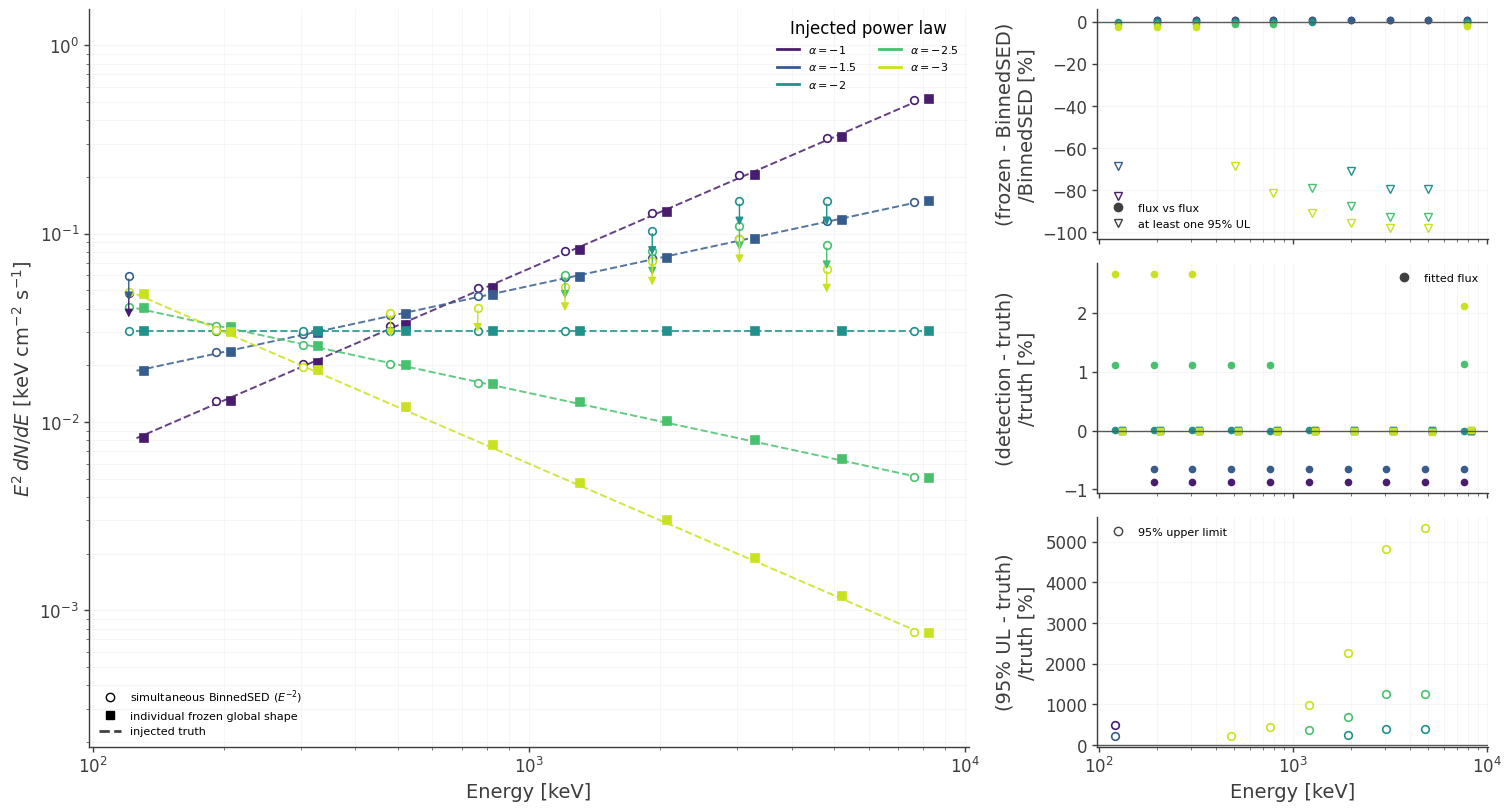

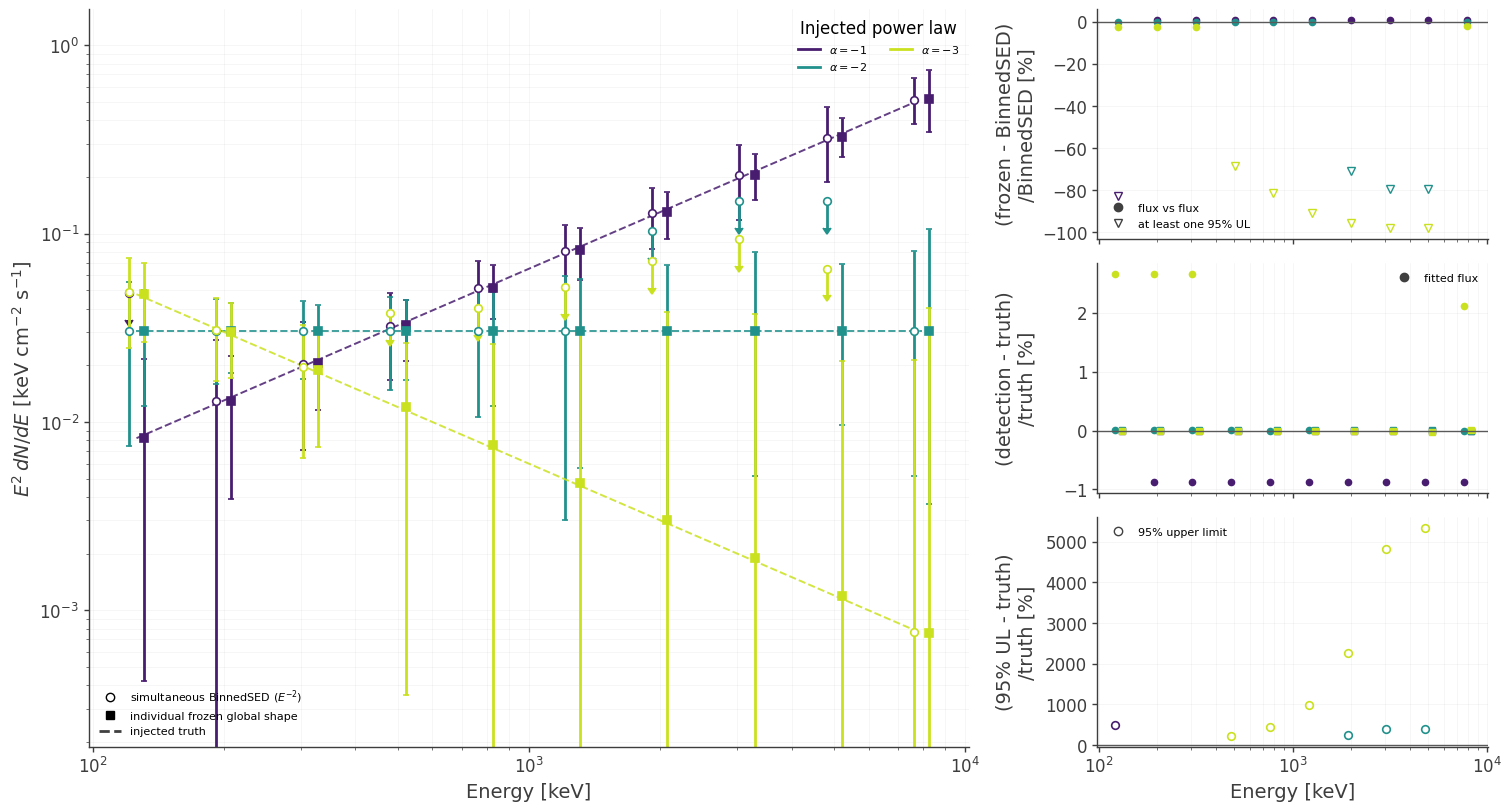

In [33]:
(
    sed_method_differences_all,
    sed_truth_differences_all,
    fig_sed_all,
) = _plot_sed_method_comparison(
    method_a="simultaneous BinnedSED",
    method_b="frozen global shape",
    label_a=r"simultaneous BinnedSED ($E^{-2}$)",
    label_b="individual frozen global shape",
    marker_a="o",
    marker_b="s",
    filled_a=False,
    filled_b=True,
    offset_a=0.96,
    offset_b=1.04,
    difference_label="(frozen - BinnedSED)\n/BinnedSED [%]",
    indices=ALL_COMPARISON_INDICES,
    show_uncertainties=False,
    output_pdf="powerlaw_sed_method_comparison_all_indices_no_uncertainties.pdf",
)

(
    sed_method_differences_selected,
    sed_truth_differences_selected,
    fig_sed_selected,
) = _plot_sed_method_comparison(
    method_a="simultaneous BinnedSED",
    method_b="frozen global shape",
    label_a=r"simultaneous BinnedSED ($E^{-2}$)",
    label_b="individual frozen global shape",
    marker_a="o",
    marker_b="s",
    filled_a=False,
    filled_b=True,
    offset_a=0.96,
    offset_b=1.04,
    difference_label="(frozen - BinnedSED)\n/BinnedSED [%]",
    indices=UNCERTAINTY_COMPARISON_INDICES,
    show_uncertainties=True,
    output_pdf=(
        "powerlaw_sed_method_comparison_"
        "selected_indices_with_uncertainties.pdf"
    ),
)

sed_method_residuals = {
    "all_indices_no_uncertainties": sed_method_differences_all,
    "selected_indices_with_uncertainties": sed_method_differences_selected,
}
sed_truth_residuals = {
    "all_indices_no_uncertainties": sed_truth_differences_all,
    "selected_indices_with_uncertainties": sed_truth_differences_selected,
}


## 9. Frozen global shape: individual versus simultaneous bins

This comparison isolates the two frozen-shape variants. Squares show the one-bin-at-a-time 3ML/Minuit fits in measured energy; diamonds show the joint 3ML/Minuit fit with all true-energy-bin normalizations free simultaneously. The global power-law index and background scale remain fixed. The first figure shows all five indices without detection uncertainty bars, while retaining upper-limit arrows. The second shows only indices $-1$, $-2$, and $-3$ with full uncertainty bars. The SED is on the left; the method difference, detection-to-truth residual, and upper-limit-to-truth residual are stacked on the right.

In [34]:
# The shared plotting helper above keeps both frozen-shape figures consistent.


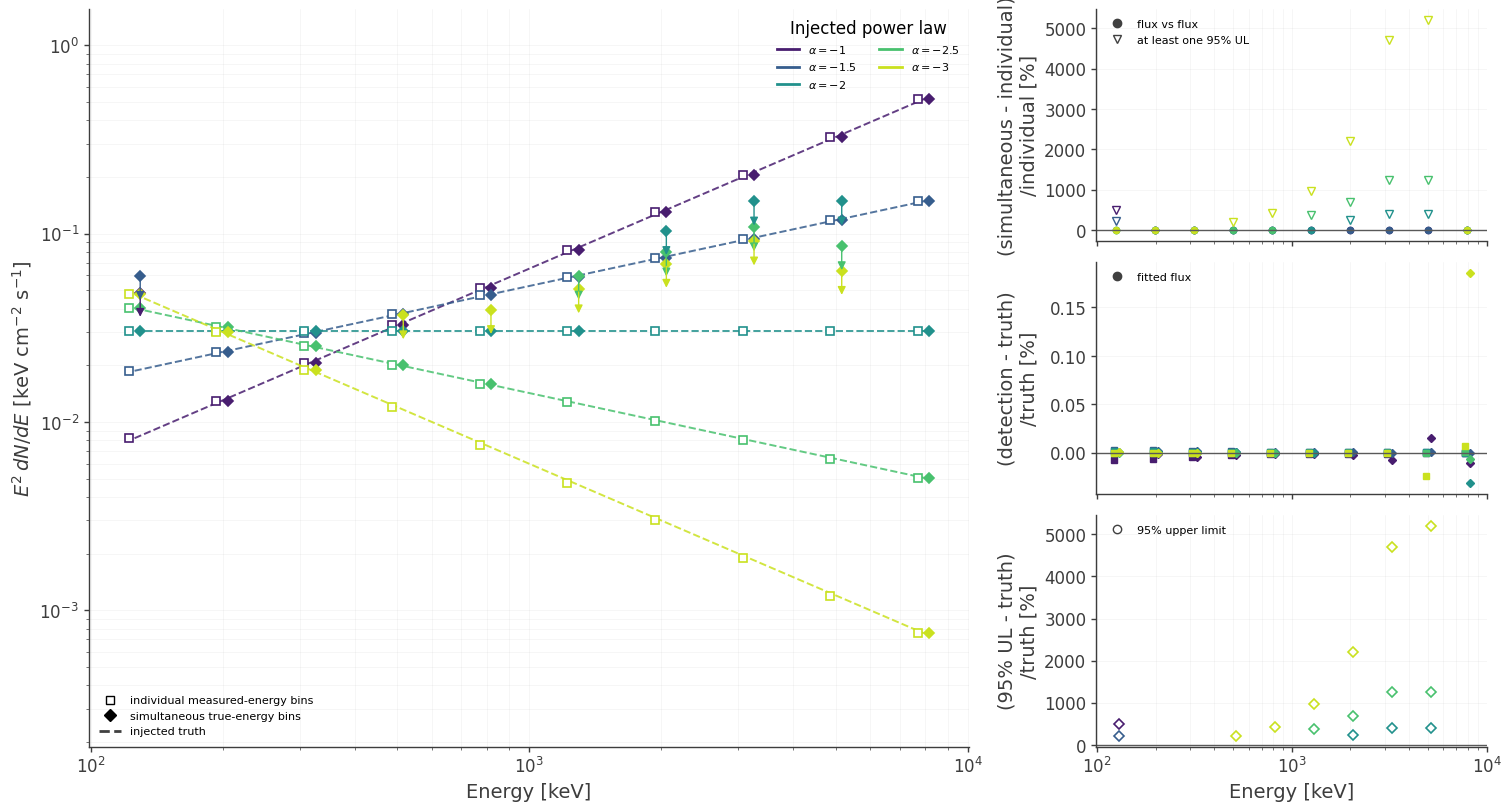

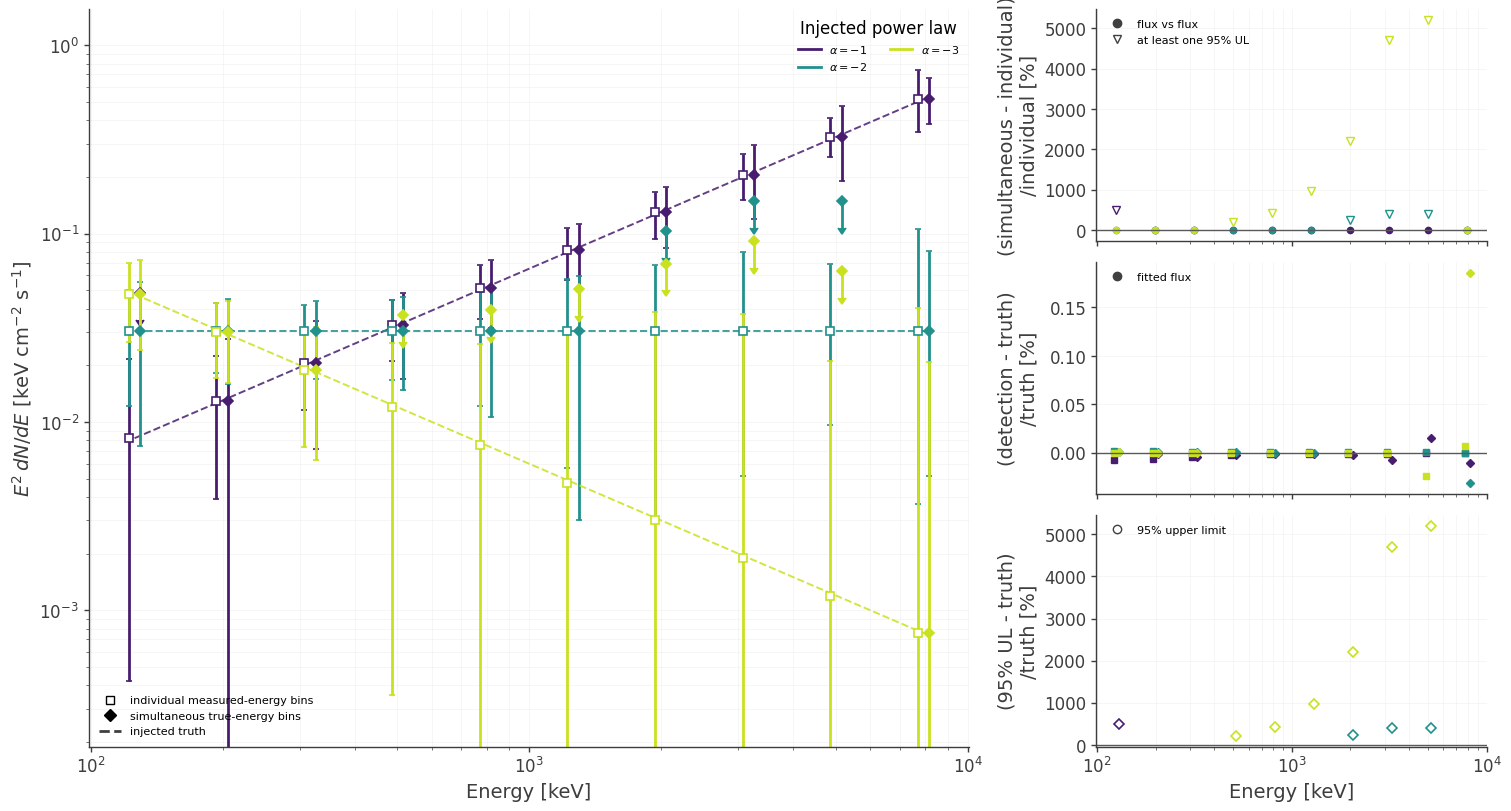

In [35]:
(
    frozen_method_differences_all,
    frozen_truth_differences_all,
    fig_frozen_all,
) = _plot_sed_method_comparison(
    method_a="frozen global shape",
    method_b="simultaneous frozen global shape",
    label_a="individual measured-energy bins",
    label_b="simultaneous true-energy bins",
    marker_a="s",
    marker_b="D",
    filled_a=False,
    filled_b=True,
    offset_a=0.97,
    offset_b=1.03,
    difference_label="(simultaneous - individual)\n/individual [%]",
    indices=ALL_COMPARISON_INDICES,
    show_uncertainties=False,
    output_pdf=(
        "frozen_shape_individual_vs_simultaneous_"
        "all_indices_no_uncertainties.pdf"
    ),
)

(
    frozen_method_differences_selected,
    frozen_truth_differences_selected,
    fig_frozen_selected,
) = _plot_sed_method_comparison(
    method_a="frozen global shape",
    method_b="simultaneous frozen global shape",
    label_a="individual measured-energy bins",
    label_b="simultaneous true-energy bins",
    marker_a="s",
    marker_b="D",
    filled_a=False,
    filled_b=True,
    offset_a=0.97,
    offset_b=1.03,
    difference_label="(simultaneous - individual)\n/individual [%]",
    indices=UNCERTAINTY_COMPARISON_INDICES,
    show_uncertainties=True,
    output_pdf=(
        "frozen_shape_individual_vs_simultaneous_"
        "selected_indices_with_uncertainties.pdf"
    ),
)

frozen_method_residuals = {
    "all_indices_no_uncertainties": frozen_method_differences_all,
    "selected_indices_with_uncertainties": frozen_method_differences_selected,
}
frozen_truth_residuals = {
    "all_indices_no_uncertainties": frozen_truth_differences_all,
    "selected_indices_with_uncertainties": frozen_truth_differences_selected,
}


## 10. BinnedSED versus simultaneous frozen global shape

Both methods fit all true-energy-bin normalizations in one joint optimization and start every bin from the same data-independent value. Open circles use the fixed local $E^{-2}$ shape of `BinnedSED`; filled diamonds use the index from the global power-law fit; dashed lines show the injected truth. Upper limits are shown when $TS < 1$. The first figure shows all five indices without detection uncertainty bars, while retaining upper-limit arrows. The second shows only indices $-1$, $-2$, and $-3$ with full uncertainty bars. The SED is on the left; the method difference, detection-to-truth residual, and upper-limit-to-truth residual are stacked on the right.

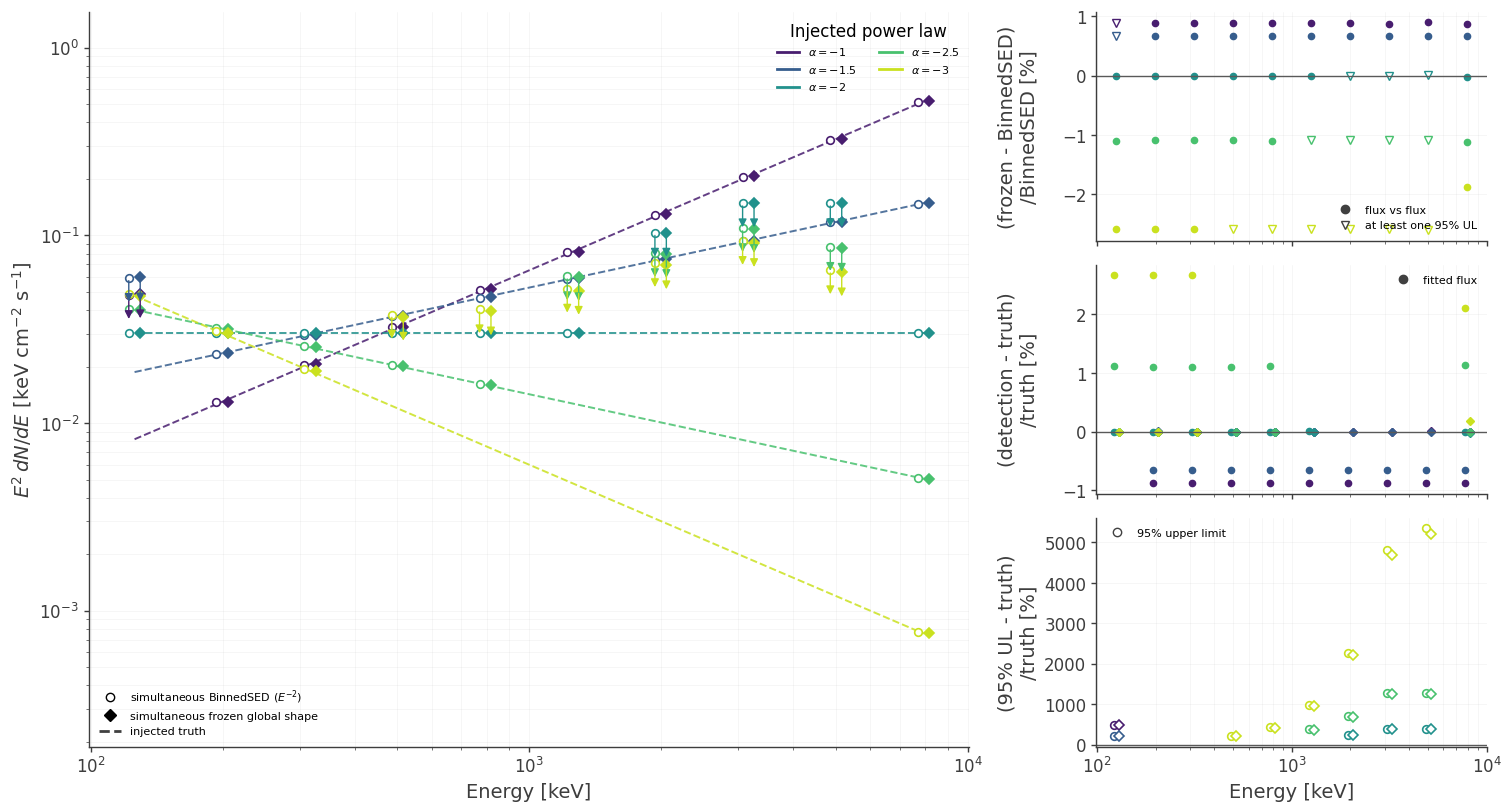

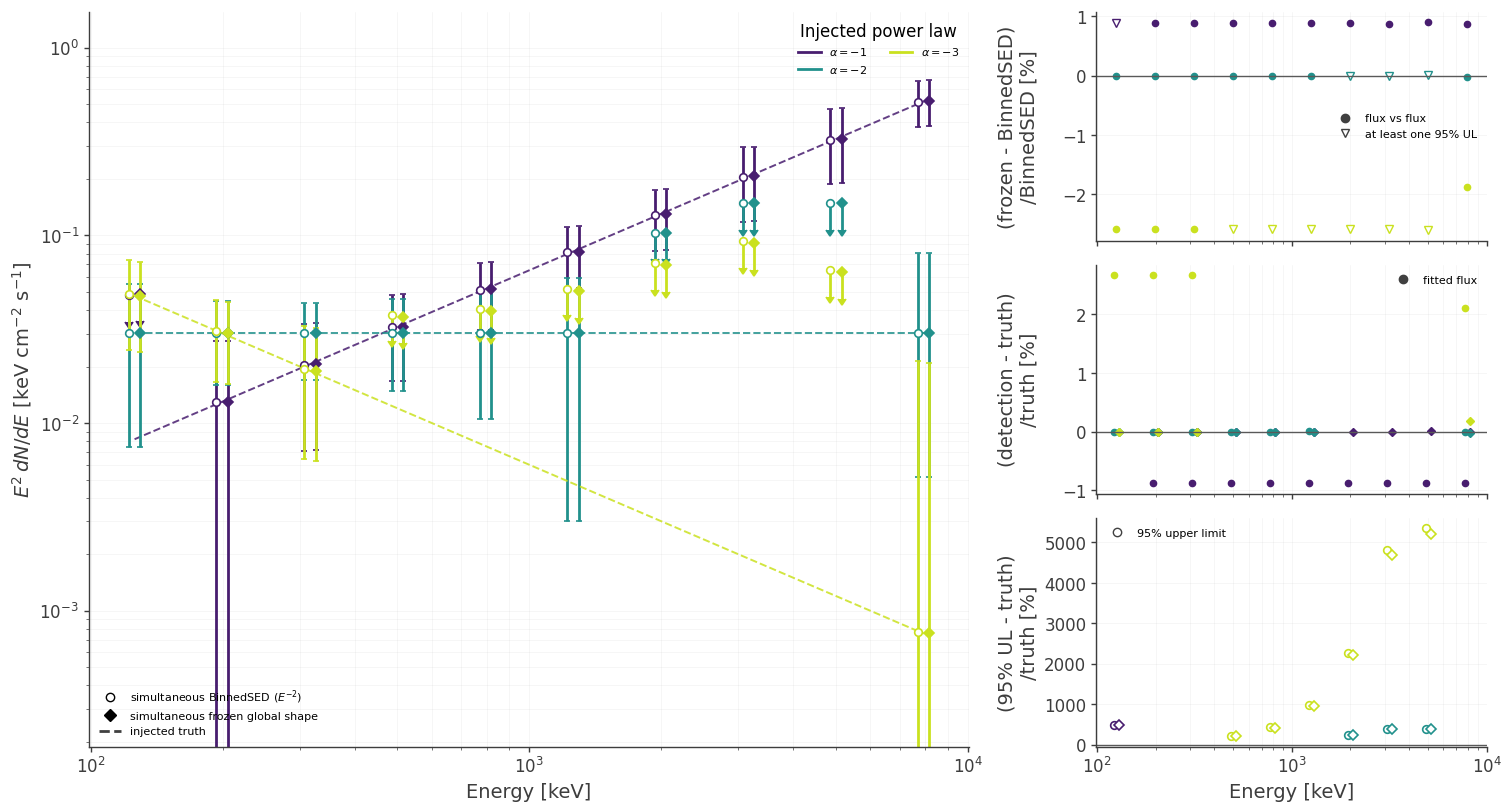

In [36]:
(
    simultaneous_method_differences_all,
    simultaneous_truth_differences_all,
    fig_simultaneous_all,
) = _plot_sed_method_comparison(
    method_a="simultaneous BinnedSED",
    method_b="simultaneous frozen global shape",
    label_a=r"simultaneous BinnedSED ($E^{-2}$)",
    label_b="simultaneous frozen global shape",
    marker_a="o",
    marker_b="D",
    filled_a=False,
    filled_b=True,
    offset_a=0.97,
    offset_b=1.03,
    difference_label="(frozen - BinnedSED)\n/BinnedSED [%]",
    indices=ALL_COMPARISON_INDICES,
    show_uncertainties=False,
    output_pdf=(
        "binned_sed_vs_simultaneous_frozen_shape_"
        "all_indices_no_uncertainties.pdf"
    ),
)

(
    simultaneous_method_differences_selected,
    simultaneous_truth_differences_selected,
    fig_simultaneous_selected,
) = _plot_sed_method_comparison(
    method_a="simultaneous BinnedSED",
    method_b="simultaneous frozen global shape",
    label_a=r"simultaneous BinnedSED ($E^{-2}$)",
    label_b="simultaneous frozen global shape",
    marker_a="o",
    marker_b="D",
    filled_a=False,
    filled_b=True,
    offset_a=0.97,
    offset_b=1.03,
    difference_label="(frozen - BinnedSED)\n/BinnedSED [%]",
    indices=UNCERTAINTY_COMPARISON_INDICES,
    show_uncertainties=True,
    output_pdf=(
        "binned_sed_vs_simultaneous_frozen_shape_"
        "selected_indices_with_uncertainties.pdf"
    ),
)

binned_vs_frozen_simultaneous_residuals = {
    "all_indices_no_uncertainties": simultaneous_method_differences_all,
    "selected_indices_with_uncertainties": simultaneous_method_differences_selected,
}
simultaneous_truth_residuals = {
    "all_indices_no_uncertainties": simultaneous_truth_differences_all,
    "selected_indices_with_uncertainties": simultaneous_truth_differences_selected,
}
